# 지구 에너지 수지 모델링

**0차원 에너지 균형 모델 소개**

이 노트북은 앨버니 대학교(University at Albany)의 [Brian E. J. Rose](https://www.atmos.albany.edu/facstaff/brose/)가 작성한 [The Climate Laboratory](https://brian-rose.github.io/ClimateLaboratoryBook)의 일부입니다.

## 1. 전 지구 에너지 수지 복습

관측 자료를 다시 한번 살펴보겠습니다 {cite:p}`Trenberth:2012a`:

![Trenberth와 Fasullo (2012)에서 관측된 전지구 에너지 흐름](https://github.com/baekmin/ClimateLaboratoryBook/blob/main/images/GlobalEnergyBudget.png?raw=1)

## 2. 복사 플럭스(Radiative Fluxes)를 관측 자료에 맞추기

### 우리의 단순 온실 모델 복습

지난 수업에서는 우주로 나가는 {term}외향 장파 복사(Outgoing Longwave Radiation)에 대한 매우 단순한 모델을 소개했습니다.

$$ \text{OLR} = \tau \sigma T_s^4 $$

여기서 $\tau$는 대기의 **투과율(Transmissivity)**로, 지구 대기의 온실 효과를 나타내는 1보다 작은 값입니다.

우리는 또한 $ \tau \approx 0.61$을 선택하여 이 모델을 관측값에 맞게 조정했습니다.

더 정확히 말하자면:

In [15]:
OLRobserved = 238.5  # in W/m2
sigma = 5.67E-8  # S-B constant
Tsobserved = 288.  # global average surface temperature
tau = OLRobserved / sigma / Tsobserved**4  # solve for tuned value of transmissivity
print(tau)

0.6114139923687016


이제 에너지 수지의 단파 복사 (태양 복사) 측면을 다루어 보겠습니다.

### 흡수 단파 복사 (ASR) 및 행성 알베도

몇 가지 용어를 정의해봅시다.

#### 전 지구 평균 일사량

먼저, 새로운 용어를 정의해 봅시다:
:::{glossary}
일사량
: 지구 대기권 상단으로 들어오는 태양 (단파) 복사 에너지.
:::

관측 결과에 따르면, 전 지구 면적 평균 {term}`일사량`은 341.3 W m⁻²입니다.

우리의 방정식과 Python 코드에서 이 양을 $Q$로 표기합시다:

In [16]:
Q = 341.3  # the insolation

#### 행성 반사율 (Planetary Albedo)

들어오는 복사 에너지 중 일부는 전혀 흡수되지 않고 단순히 우주 공간으로 다시 반사됩니다. 이 양을 $F_{reflected}$라고 부릅시다.

관측을 통해 다음을 알 수 있습니다:

In [17]:
Freflected = 101.9  #  reflected shortwave flux in W/m2

**행성 반사율** (planetary albedo)은 $Q$ 중 반사되는 비율입니다.

우리는 행성 반사율을 $\alpha$로 표기할 것입니다.

관측에서:

In [18]:
alpha = Freflected / Q
print(alpha)

0.29856431292118374


즉, 입사 복사(incoming radiation)의 약 30%는 우주 공간으로 반사됩니다.

#### 흡수된 단파 복사

이제 핵심 용어 하나를 공식적으로 정의하겠습니다:

:::{glossary}
흡수된 단파 복사
: 일사량(Insolation) 중 우주로 *반사되지 않는* 부분, 즉 지구 시스템 내 어딘가에 흡수되는 부분입니다 (종종 ASR로 약칭됩니다).
:::

수학적으로는 다음과 같이 표현합니다:

$$ \text{ASR} = Q - F_{reflected} = (1-\alpha) Q $$

관측 자료에 따르면:

In [19]:
ASRobserved = Q - Freflected
print(ASRobserved)

239.4


지난번에 언급했듯이, 이 수치는 관측된 238.5 W m⁻²의 방출 장파 복사(OLR)보다 *약간 더 크다*.

## 3. 평형 온도

:::{important}
이것은 기후 모델링의 핵심 개념 중 하나입니다.
:::

지구 시스템은 유입 에너지 = 유출 에너지일 때, 즉 **에너지 균형** 상태에 있습니다.

$$ \text{ASR} = \text{OLR} $$

우리가 알고자 하는 것은 다음과 같습니다:

- 이러한 균형을 이루기 위해 필요한 표면 온도는 얼마인가?
- 지구 시스템의 다른 변화(change)에 대한 반응으로 온도가 얼마나 변할 것인가?
    - 온실 가스(greenhouse gases) 변화
    - 운량(cloudiness) 변화
    - 기타

우리의 단순 온실 모델을 사용하면, 평형 온도에 대한 **정확한 해**를 얻을 수 있습니다.

먼저, 우리의 에너지 균형식을 적어보겠습니다:

$$ (1-\alpha) Q = \tau \sigma T_s^4 $$

$T_s$에 대해 풀기 위해 식을 재정렬하면 다음과 같습니다:

$$ T_s^4 = \frac{(1-\alpha) Q}{\tau \sigma} $$

그리고 네제곱근을 취하면, 우리의 **평형 온도**(equilibrium temperature)를 $T_{eq}$로 나타낼 수 있습니다:

$$ T_{eq} = \left( \frac{(1-\alpha) Q}{\tau \sigma} \right)^\frac{1}{4} $$

관측값을 다시 대입하여 계산하면 다음과 같습니다:

In [20]:
#  define a reusable function!
def equilibrium_temperature(alpha,Q,tau):
    return ((1-alpha)*Q/(tau*sigma))**(1/4)

Teq_observed = equilibrium_temperature(alpha,Q,tau)
print(Teq_observed)

288.27131447889224


그리고 이 평형 온도는 *288 K보다 아주 약간 더 높습니다*. 왜일까요?

## 4. 기후 변화 시나리오

지구 온난화(대기 조성의 변화 및 그에 따른 구름 양의 변화)로 인해 다음 상황이 발생했다고 가정해봅시다:

-   장파 투과율(longwave transmissivity)이 $\tau = 0.57$로 감소합니다.
-   행성 알베도(planetary albedo)가 $\alpha = 0.32$로 증가합니다.

***새로운 평형 온도***는 얼마일까요?

이 매우 단순한 모델의 경우, 우리는 답을 정확히 구할 수 있습니다:

In [21]:
Teq_new = equilibrium_temperature(0.32,Q,0.57)
#  an example of formatted print output, limiting to two or one decimal places
print('The new equilibrium temperature is {:.2f} K.'.format(Teq_new))
print('The equilibrium temperature increased by about {:.1f} K.'.format(Teq_new-Teq_observed))

The new equilibrium temperature is 291.10 K.
The equilibrium temperature increased by about 2.8 K.


대부분의 기후 모델은 수학적으로 더 복잡하기 때문에, 평형 온도(equilibrium temperature)를 직접적으로 구하는 것은 불가능할 것입니다!

대신, 우리는 모델을 활용하여 에너지 수지(energy budget)의 항들(ASR과 OLR)을 계산할 수 있을 것입니다.

### Python 실습

- *임의의 매개변수 값*에 대해 흡수 태양 복사(ASR)와 외향 장파 복사(OLR)를 계산하는 Python 함수를 작성하세요.
- 다음 사항을 확인하세요:
    - 새로운 매개변수 값을 사용하되 이전 온도 $T = 288$ K를 사용할 때, ASR이 OLR보다 큰가요, 작은가요?
    - 지구는 에너지를 얻고 있는가요, 잃고 있는가요?
    - 만약 $T = 295$ K (또는 291 K보다 큰 다른 어떤 온도라도)라면 당신의 답변은 어떻게 달라지나요?

## 5. 시간 의존적인 에너지 균형 모델

위 연습은 만약 기후 시스템의 일부 특성이 **평형 온도**가 상승하는 방식으로 변한다면, 지구 시스템은 *우주로 잃는 에너지보다 태양으로부터 더 많은 에너지를 받게 된다*는 것을 보여줍니다. 시스템은 더 이상 **에너지 균형(energy balance)** 상태가 아닙니다.

온도는 균형 상태로 되돌아가기 위해 상승해야 합니다. 이러한 증가는 한꺼번에 일어나지 않을 것입니다! 기후 시스템에 에너지가 축적되는 데는 시간이 걸릴 것입니다. 우리는 이러한 시스템의 **시간 의존적 조정(time-dependent adjustment)**을 모델링하고자 합니다.

사실 거의 모든 기후 모델은 **시간 의존적(time-dependent)**이며, 이는 모델이 기후 변수의 **시간 미분(time derivatives)** (변화율)을 계산한다는 것을 의미합니다.

### 에너지 균형 **방정식**

우리는 지구 시스템의 **총 에너지 수지(total energy budget)**를 다음과 같이 표현할 것입니다:

$$
\begin{align}
\frac{dE}{dt} &= \text{net energy flux in to system} \\
 &= \text{flux in – flux out} \\
 &= \text{ASR} - \text{OLR}
\end{align}
$$

여기서 $E$는 전체 시스템의 **엔탈피(enthalpy)** 또는 **열함량(heat content)**입니다.

우리는 이 수지를 **단위 표면적당**으로 표현할 것이며, 따라서 위의 각 항은 W m⁻²의 단위를 가집니다.

참고: 서로 다른 저장고(reservoir)들(예: 해양, 육지, 얼음, 대기 사이) 간의 어떤 **내부 에너지 교환**도 이 수지에는 나타나지 않습니다 — 왜냐하면 $E$는 **모든 저장고의 합계**이기 때문입니다.

또한 주목할 점은: **이것은 일반적으로 참인 진술입니다.** 우리는 단지 몇 가지 용어를 정의하고, 유일하게 중요한 에너지원은 우주와의 복사 교환이라는 (매우 합리적인) 가정을 했을 뿐입니다.

**이 방정식은 모든 기후 모델의 출발점입니다.**

하지만 아직까지는 실제로 모델을 가지고 있지 않습니다. 우리는 단지 수지에 대한 설명만 있을 뿐입니다. 이 수지를 사용하여 모델을 만들려면, 우리는 수지 내의 항들을 대기-해양 시스템의 상태 변수와 연결해야 합니다.

현재로서는 우리가 가장 관심을 갖는 상태 변수는 **온도**입니다. 왜냐하면 온도가 위에 언급된 각 항의 물리량과 직접적으로 연결되어 있기 때문입니다.

### 에너지 균형 **모델**

이제 우리가 다음과 같이 가정한다면

$$ E = C T_s $$

여기서 $T_s$는 **전지구 평균 지표면 온도**이고, $C$는 상수인데, 이는 대기-해양 기둥(atmosphere-ocean column)의 **유효 열용량**입니다.

그러면 우리의 수지 방정식(budget equation)은 다음과 같이 됩니다:

$$ C \frac{dT_s}{dt} = \text{ASR} - \text{OLR} $$

여기서,

- $C$는 지구 시스템의 열용량(heat capacity)이며, 단위는 J m⁻² K⁻¹입니다.
- $\frac{dT_s}{dt}$는 전지구 평균 지표 온도의 변화율입니다.

이 방정식을 채택함으로써, 우리는 지구 시스템(대기, 해양, 얼음 등)의 에너지 함량이 *표면 온도에 비례한다*고 가정하고 있습니다.

고려해야 할 중요한 사항들:

- 왜 이것이 타당한 가정인가요?
- 열용량(Heat Capacity) $C$는 무엇에 의해 결정되나요?
- 이 가정의 몇 가지 한계점은 무엇인가요?

여기서 우리는 100미터 깊이의 물을 가열하는 데 해당하는 C 값을 사용할 것입니다:

$$C = c_w \rho_w H$$

여기서

$c_w = 4 \times 10^3$ J kg⁻¹ K⁻¹ 는 물의 비열(specific heat)이고,

$\rho_w = 10^3$ kg m⁻³ 는 물의 밀도(density)이며,

$H$ 는 가열되거나 냉각되는 물의 유효 깊이(effective depth)입니다.

In [22]:
c_w = 4E3  #  Specific heat of water in J/kg/K
rho_w = 1E3  #  Density of water in kg/m3
H = 100.   #  Depth of water in m
C = c_w * rho_w * H   #  Heat capacity of the model
print('The effective heat capacity is {:.1e} J m⁻² K⁻¹'.format(C))

The effective heat capacity is 4.0e+08 J m⁻² K⁻¹


### 에너지 균형 모델 풀이

이것은 시간을 함수로 하는 $T_s$에 대한 1차 상미분 방정식(ODE)입니다. 이것은 또한 **우리의 첫 번째 기후 모델입니다!**

이것을 풀기 위해 (즉, 지정된 초기 조건에서 $T_s$가 어떻게 진화하는지 보기 위해) 우리는 두 가지 선택지가 있습니다:

1. 해석적으로 풀기
2. 수치적으로 풀기

옵션 1 (해석적 방식)은 방정식들이 일반적으로 너무 복잡하고 비선형적이기 때문에 대개 가능하지 않습니다. 이것이 바로 기후 모델링(climate modeling) 분야에서 컴퓨터가 우리의 가장 좋은 친구인 이유입니다.

하지만 가능할 때 모델을 해석적으로 풀 수 있는 수준으로 단순화하는 것이 종종 유용하고 교육적입니다. 왜일까요? 두 가지 이유가 있습니다:

1. 해석은 종종 시스템의 행동에 대한 더 깊은 이해를 제공합니다.
2. 우리의 수치적 해답(numerical solutions)의 결과를 테스트할 수 있는 기준점(benchmark)을 제공합니다.

## 6. 컴퓨터에서 시간 미분 표현하기

미분(derivative)은 **순간 변화율**임을 상기합시다. 이는 다음과 같이 정의됩니다:

$$ \frac{dT}{dt} = \lim_{\Delta t\rightarrow 0}⁡ \frac{\Delta T}{\Delta t}$$

- **컴퓨터에서는 순간적인 변화라는 것이 존재하지 않습니다.**
- 우리는 항상 *이산량(discrete quantities)*을 다룹니다.
- 따라서 우리는 미분(derivative)을 $\Delta T/ \Delta t$로 근사합니다.
- 시간 간격 $\Delta t$를 *충분히 작게* 취하는 한, 이 근사는 유효하고 유용합니다.
- ("충분히 작게"의 의미는 실제로는 매우 다양합니다. 지금은 이에 대해 이야기하지 맙시다)

따라서 우리는 모델을 다음과 같이 작성합니다.

$$ C  \frac{\Delta T}{\Delta t} \approx \text{ASR} - \text{OLR}$$

여기서 $\Delta T$는 짧은 시간 간격 $\Delta t$ 동안 **우리 모델이 예측하는 온도 변화**입니다.

이제 이를 사용하여 **예측을 수행할 수 있습니다**:

현재 시간 $t_1$에서의 온도 $T_1$이 주어졌을 때, 미래 시간 $t_2$에서의 온도 $T_2$는 얼마일까요?

우리는 다음과 같이 쓸 수 있습니다

$$ \Delta T = T_2-T_1 $$
$$ \Delta t = t_2-t_1 $$

따라서 우리의 모델은 다음과 같이 설명합니다:

$$ C \frac{T_2-T_1}{\Delta t} = \text{ASR} - \text{OLR} $$

이를 재배열하여 **미래 온도를 구할 수 있습니다**:

$$ T_2 = T_1 + \frac{\Delta t}{C} \left( \text{ASR} - \text{OLR}(T_1) \right) $$

이제 우리는 예측을 할 수 있는 공식을 갖게 되었습니다!

여기서 우리는 외향 장파 복사(OLR)를 *온도의 함수*로 작성했음에 주목하십시오. 우리는 현재 온도 $T_1$를 사용하여 외향 장파 복사(OLR)를 계산하고, 그 외향 장파 복사(OLR)를 이용하여 미래 온도를 결정할 것입니다.

## 7. 에너지 균형 모델의 수치 해

양 $\Delta t$는 **시간 단계(timestep)**라고 불립니다. 이는 우리 모델에서 표현되는 가장 작은 시간 간격입니다.

여기서 우리는 1년의 시간 단계를 사용할 것입니다:

In [23]:
dt = 60. * 60. * 24. * 365.   # one year expressed in seconds

### 한 시간 단계 앞으로 나아가 보세요

In [25]:
# Try a single timestep, assuming we have working functions for ASR and OLR
T1 = 288.
T2 = T1 + dt / C * ( ASR(alpha=0.32) - OLR(T1, tau=0.57) )
print(T2)

NameError: name 'OLR' is not defined

***여기서 `NameError`가 발생했나요?***

위 코드는 우리가 이미 함수 `ASR()`와 `OLR()`를 정의했다고 가정합니다. 만약 위의 실습을 완료하지 않았다면, 이 코드는 작동하지 않을 것입니다.

이제 위에서 만들기로 했던 함수들을 정의해 봅시다:

In [26]:
def ASR(Q=Q, alpha=alpha):
    return (1-alpha)*Q

def OLR(T, tau=tau):
    return tau * sigma * T**4

이제 다시 해보겠습니다...

In [27]:
# Try a single timestep, assuming we have working functions for ASR and OLR
T1 = 288.
T2 = T1 + dt / C * ( ASR(alpha=0.32) - OLR(T1, tau=0.57) )
print(T2)

288.7678026614462


무슨 일이 일어났나요? 왜인가요?

다른 시간 단계를 시도해보세요.

In [28]:
T1 = T2
T2 = T1 + dt / C * ( ASR(alpha=0.32) - OLR(T1, tau=0.57) )
print(T2)

289.3479210238739


기온이 다시 상승했지만, 그 상승폭은 더 작았습니다.

하지만 이것은 번거로운 타이핑입니다. 일을 더 쉽고 더 신뢰할 수 있도록 **함수를 정의**할 때입니다:

In [29]:
def step_forward(T):
    return T + dt / C * ( ASR(alpha=0.32) - OLR(T, tau=0.57) )

임의의 온도로 시도해 보세요:

In [36]:
def step_forward_bm(T,tau):
    return T + dt / C * ( ASR(alpha=0.32) - OLR(T, tau) )

In [30]:
step_forward(300.)

297.658459884

우리의 함수가 이미 정의된 다른 함수들과 변수들을 호출한다는 점에 유의하세요.

:::{tip} 파이썬 사실 10
**함수는 함수 외부에 정의된 변수 및 다른 함수에 접근할 수 있습니다.**

이는 매우 유용하면서도 때로는 혼란을 야기할 수 있습니다.
:::

### 반복문을 이용한 시간 단계(timestepping) 자동화

이제 **반복문(loop)을 만들고** (값을 배열(array)에 저장하여) 컴퓨터의 진정한 힘을 활용해 봅시다:

In [53]:
import numpy as np

numsteps = 20
Tsteps = np.zeros(numsteps+1)
Years = np.zeros(numsteps+1)
Tsteps[0] = 288.
for n in range(numsteps):
    Years[n+1] = n+1
    Tsteps[n+1] = step_forward( Tsteps[n] )
print(Tsteps)

[288.         288.76780266 289.34792102 289.78523685 290.11433323
 290.36166675 290.54736768 290.68669049 290.79115953 290.86946109
 290.92813114 290.97208122 291.00499865 291.02964965 291.0481083
 291.06192909 291.07227674 291.08002371 291.08582346 291.09016532
 291.09341571]


우리가 방금 무엇을 했나요?

- 0으로 구성된 배열을 생성했습니다.
- 초기 온도를 288 K로 설정했습니다.
- 시간 단계를 20번 반복했습니다.
- 각 시간 단계의 결과를 배열에 저장했습니다.

:::{tip} 파이썬 사실 11
``for`` 문은 지정된 횟수만큼 문(또는 일련의 문)을 실행합니다 (반복문입니다!).
:::

:::{tip} 파이썬 팁 12
배열이나 리스트의 요소들을 지칭할 때는 대괄호 [ ]를 사용합니다. 함수 인자에는 소괄호 ( )를 사용합니다.
:::

### 결과 도식화

이제 우리의 결과를 그림으로 그려봅시다!

In [54]:
# a special instruction for the Jupyter notebook
#   Display all plots inline in the notebook
%matplotlib inline
#  import the plotting package
import matplotlib.pyplot as plt

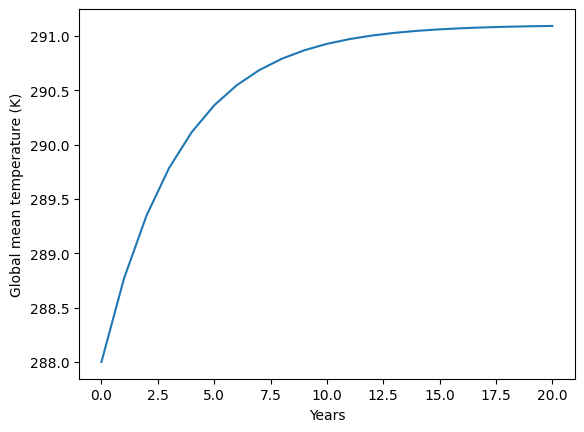

In [55]:
plt.plot(Years, Tsteps)
plt.xlabel('Years')
plt.ylabel('Global mean temperature (K)');

온도가 *평형 온도 쪽으로 부드럽게 조정되는* 방식을 주목하세요. 평형 온도란 즉, 흡수된 태양 복사량(ASR) = 방출되는 장파 복사량(OLR)인 온도입니다.

**행성 에너지 수지(planetary energy budget)가 불균형하면, 방출되는 장파 복사량(OLR)이 흡수된 태양 복사량(ASR)에 더 가까워지도록 온도가 변해야 합니다!**

이러한 조정은 사실 *지수적 감소(exponential decay)* 과정입니다. 온도가 평형에 가까워질수록 조정 속도는 느려집니다.

온도는 평형에 매우 가깝게 도달하지만, 정확히 평형에 이르지는 않습니다.

:::{tip} 파이썬 정보 13
`plt.plot(x,y)` 함수를 사용하면 간단한 그래프를 쉽게 만들 수 있습니다. 여기서 `x`와 `y`는 동일한 크기의 배열입니다. 하지만 먼저 임포트(import)해야 합니다.

이것은 사실 파이썬 자체의 기능이 아니라 [matplotlib](https://matplotlib.org)이라는 그래픽 라이브러리를 사용합니다. 이것은 파이썬에서 과학적 플로팅(scientific plotting)의 핵심 도구이며, 우리는 항상 이것을 사용할 것입니다!

거의 모든 노트북은 다음과 같이 시작할 것입니다:
```
import numpy as np
import matplotlib.pyplot as plt
```
:::

In [59]:
import numpy as np

numsteps = 20
Tsteps = np.zeros(numsteps+1)
Years = np.zeros(numsteps+1)
Tsteps[0] = 288.
tau_tmp=0.57
for n in range(numsteps):
    tau_tmp=tau_tmp-0.0005
    Years[n+1] = n+1
    Tsteps[n+1] = step_forward_bm( Tsteps[n],tau_tmp )
print(Tsteps)

[288.         288.78317959 289.39061359 289.86441441 290.2369808
 290.53307306 290.77151962 290.96658482 291.12904512 291.26702506
 291.38664049 291.49248994 291.58802819 291.67584919 291.75789971
 291.83564038 291.91016683 291.98230083 292.05265867 292.12170255
 292.18977911]


In [60]:
# a special instruction for the Jupyter notebook
#   Display all plots inline in the notebook
%matplotlib inline
#  import the plotting package
import matplotlib.pyplot as plt

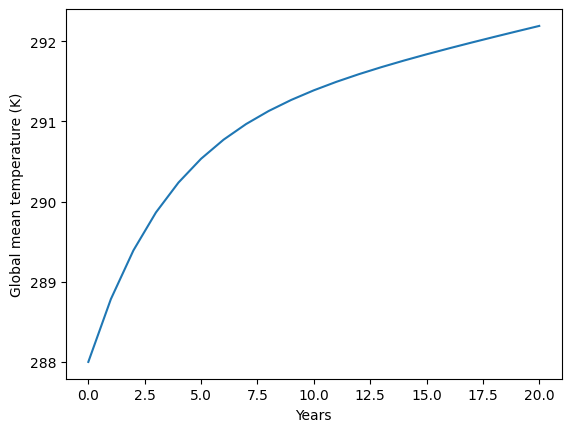

In [61]:
plt.plot(Years, Tsteps)
plt.xlabel('Years')
plt.ylabel('Global mean temperature (K)');

## 8. 요약 및 핵심 메시지

- 우리는 지구 시스템으로 들어오고 나가는 에너지 흐름을 살펴보았습니다.
- 이들은 지구 대기권 상단에서의 복사 에너지에 의해 결정됩니다.
- 흡수된 단파 복사(ASR)와 방출 장파 복사(OLR) 사이의 불균형은 온도 변화를 야기합니다.
- 이 아이디어를 사용하여 우리는 기후 모델을 구축했습니다!
- 이 **0차원 에너지 균형 모델**(Zero-Dimensional Energy Balance Model)은 전 지구 연평균 지표면 온도 $T_s$를 계산합니다.
- 두 가지 주요 가정:
    - 지구 시스템의 에너지 함량은 $T_s$에 비례하여 변합니다.
    - OLR은 $\tau \sigma T_s^4$에 따라 증가합니다 (우리의 간단한 온실 모델).
- 지구(또는 다른 행성)는 *방출 장파 복사의 온도 의존성* 때문에 ASR = OLR이 되는 잘 정의된 **평형 온도**(equilibrium temperature) $T_{eq}$를 가집니다.

- 만약 $T_s < T_{eq}$라면, 모델은 온난화될 것입니다.
- 우리는 연속적인 온난화 과정을 컴퓨터에서 이산 시간 간격(discrete timesteps)을 사용하여 표현할 수 있습니다.
- 우리는 그 결과를 플로팅할 수 있습니다.
- transmissivity $\tau$를 일정하다고 가정할수 있나요?
- 지구온난화로 인해 이산화탄소가 계속 증가한다는 것은 transmissivity가 어떻게 된다는 뜻일까요?
- transmissivity가 계속 줄어든다면 지구의 온도는 어떻게 될까요? 그래도 평형상태로 갈까요?


실습

온실가스 농도 증가 추이 그래프를 웹에서 찾아서 여기에 그리시오.
배출량 추이 그래프를 웹에서 찾아서 여기에 그리시오.

인류가 드디어 온실가스 배출을 감축하기 시작해서 대기중 온실기체 농도가 낮아지기 시작했다.
1년에 transmissivity가 무려 0.0002씩 감소하기 시작했다. 지구 온도 변화 그래프를 그려보시오.




## 출처
____________

이 노트북은 Albany 대학교의 [Brian E. J. Rose](https://www.atmos.albany.edu/facstaff/brose/) 교수에 의해 개발 및 유지관리되는 개방형 교재인 [기후 연구실](https://brian-rose.github.io/ClimateLaboratoryBook)의 일부입니다.

이 자료는 [크리에이티브 커먼즈 저작자표시 4.0 국제(CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/) 라이선스에 따라 자유롭게 이용할 수 있습니다.

본 자료와 [climlab 소프트웨어](https://github.com/climlab/climlab)의 개발은 Brian Rose에게 부여된 미국 국립과학재단(National Science Foundation)의 과제 번호 AGS-1455071의 부분적인 지원을 받습니다. 여기서 표현된 어떠한 의견, 연구 결과, 결론 또는 권고사항도 전적으로 저의 것이며, 반드시 미국 국립과학재단의 견해를 반영하는 것은 아닙니다.